# Task 6: Visualizations
## Customer Churn Analysis and Prediction — SaiKet Systems Data Analysis Internship

**Task:** 6 of 6 (extended deliverable)

---

## 1. Objective
Consolidate and extend the project's visual analysis into one dedicated visualization notebook,
covering the chart types the brief specifically calls out (box plot, violin plot, pair plot) plus
the other key relationships explored across Tasks 2–4, each saved as a standalone chart file.

## 2. Dataset
Uses the segmented dataset produced in Task 3 (`Task_3_Segmented_Dataset.csv`), which already
contains the cleaned/encoded fields plus tenure, charges, and priority segments.


## 3. Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5.5)
plt.rcParams['font.size'] = 11

os.makedirs('charts', exist_ok=True)


## 4. Load Dataset

In [2]:
df = pd.read_csv('../Task_3_Customer_Segmentation/Task_3_Segmented_Dataset.csv')
df['Churn_Label'] = df['Churn'].map({1: 'Yes', 0: 'No'})
print(df.shape)
df.head(3)


(7043, 28)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,Tenure_Segment,Charges_Segment,Combined_Segment,Value_Tier,Risk_Tier,Priority_Segment,Churn_Label
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,29.85,29.85,0,New (0-12mo),Low (<=$35),New (0-12mo) | Low (<=$35) | Month-to-month,Low Value,High Risk,Low Value + High Risk,No
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,56.95,1889.50,0,Established (25-48mo),Medium ($35-$70),Established (25-48mo) | Medium ($35-$70) | One...,Low Value,Low Risk,Low Value + Low Risk,No
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,53.85,108.15,1,New (0-12mo),Medium ($35-$70),New (0-12mo) | Medium ($35-$70) | Month-to-month,Low Value,High Risk,Low Value + High Risk,Yes


## 5. Churn Distribution

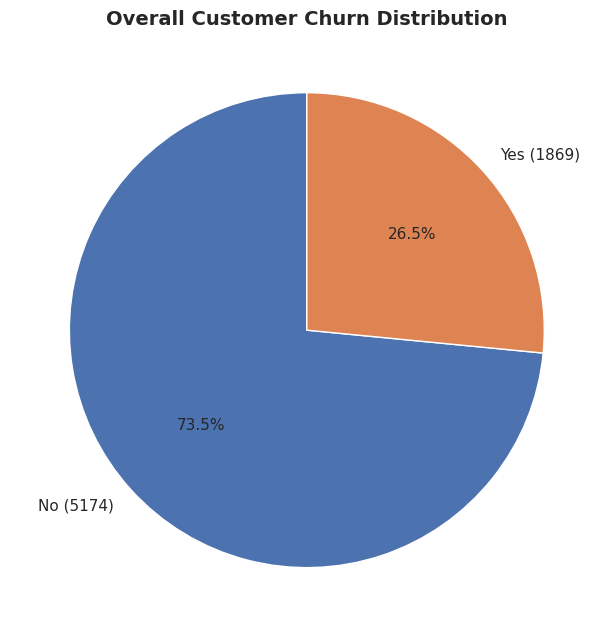

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
counts = df['Churn_Label'].value_counts()
ax.pie(counts, labels=[f"{l} ({v})" for l, v in counts.items()], autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'], startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_churn_distribution.png', dpi=150)
plt.show()


**Insight:** 26.54% of customers have churned — the baseline every other chart is compared against.

## 6. Tenure Distribution

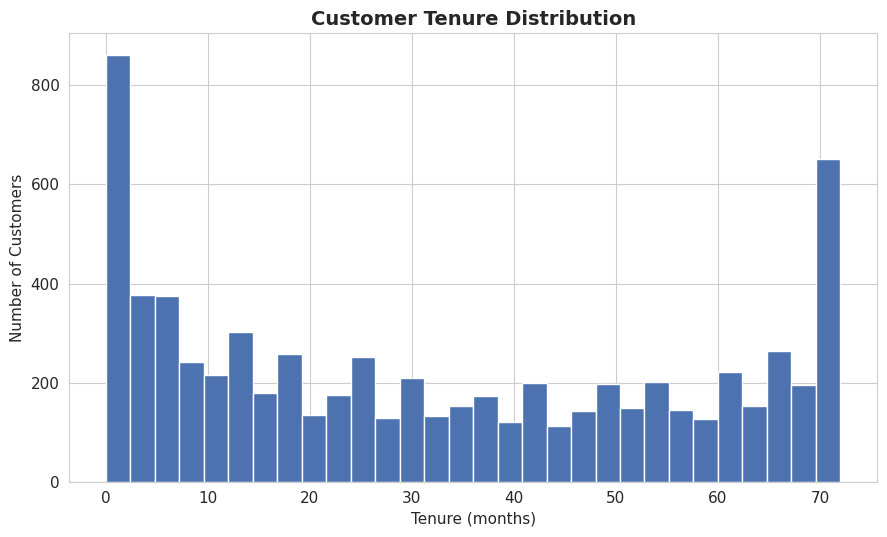

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(df['tenure'], bins=30, color='#4C72B0', edgecolor='white')
ax.set_title('Customer Tenure Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('charts/02_tenure_distribution.png', dpi=150)
plt.show()


**Insight:** Tenure is bimodal — a large group of very new customers (0–5 months) and a large group of long-tenured customers near 72 months, with fewer customers in between.

## 7. Box Plot — Monthly Charges by Churn Status

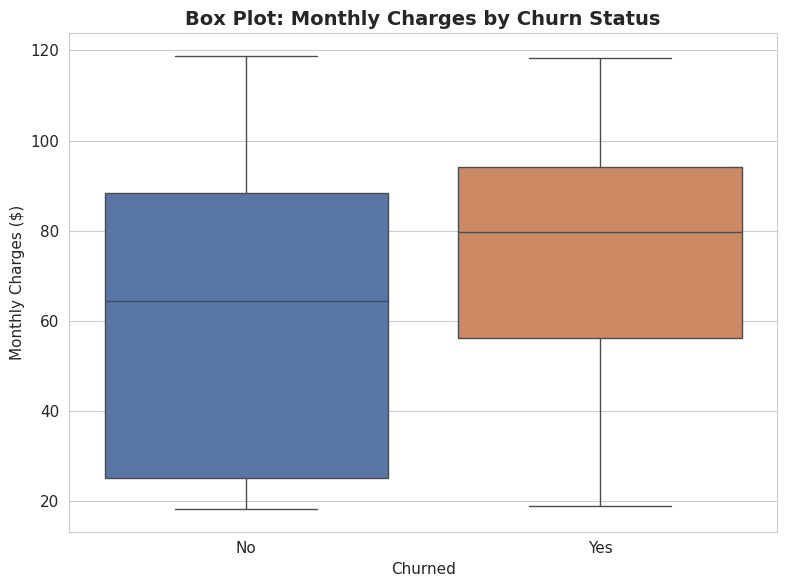

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='Churn_Label', y='MonthlyCharges', hue='Churn_Label',
            palette=['#4C72B0', '#DD8452'], ax=ax, legend=False)
ax.set_title('Box Plot: Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Churned')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('charts/03_boxplot_monthlycharges_churn.png', dpi=150)
plt.show()


**Insight:** The box plot shows churned customers have a visibly higher median and interquartile range of monthly charges than retained customers, confirming the Task 2 finding that churners tend to be on pricier plans.

## 8. Violin Plot — Tenure by Churn Status

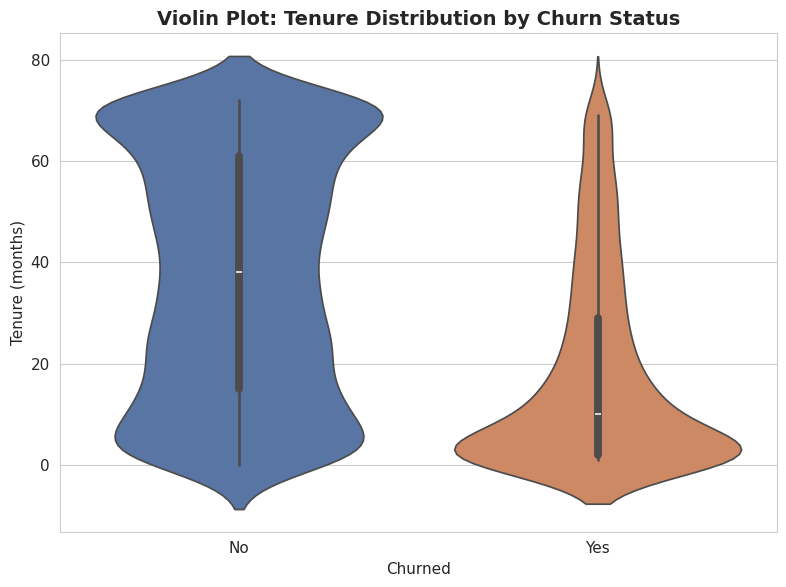

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df, x='Churn_Label', y='tenure', hue='Churn_Label',
               palette=['#4C72B0', '#DD8452'], ax=ax, legend=False)
ax.set_title('Violin Plot: Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Churned')
ax.set_ylabel('Tenure (months)')
plt.tight_layout()
plt.savefig('charts/04_violinplot_tenure_churn.png', dpi=150)
plt.show()


**Insight:** The violin plot shows churned customers' tenure distribution is heavily concentrated near 0, while retained customers' distribution is much wider and skews toward higher tenure — visually reinforcing that most churn happens early in the customer relationship.

## 9. Violin Plot — Total Charges by Contract Type

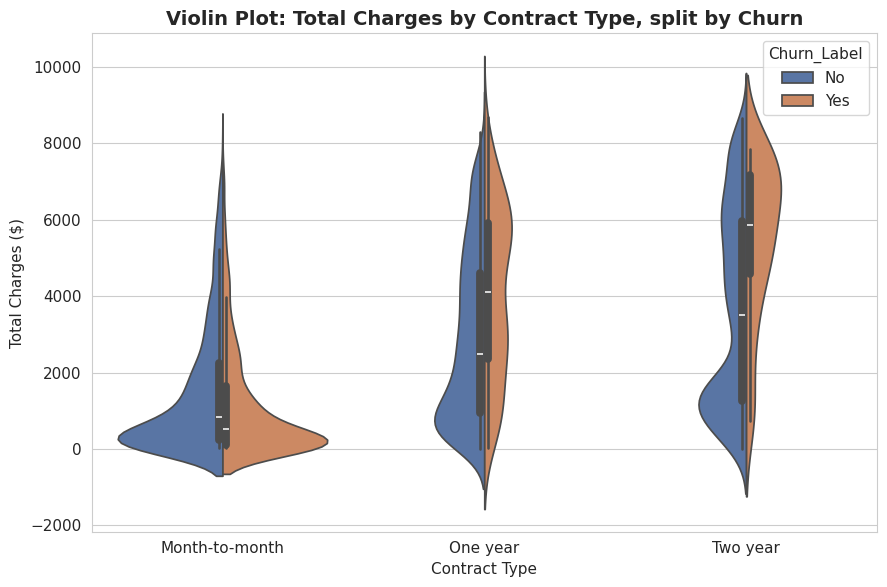

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(data=df, x='Contract', y='TotalCharges', hue='Churn_Label',
               palette=['#4C72B0', '#DD8452'], split=True, ax=ax)
ax.set_title('Violin Plot: Total Charges by Contract Type, split by Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Total Charges ($)')
plt.tight_layout()
plt.savefig('charts/05_violinplot_totalcharges_contract.png', dpi=150)
plt.show()


**Insight:** Within every contract type, churned customers (orange) cluster at lower total charges than retained customers (blue) — consistent with churners leaving before accumulating revenue, regardless of contract type.

## 10. Pair Plot — Numeric Relationships by Churn

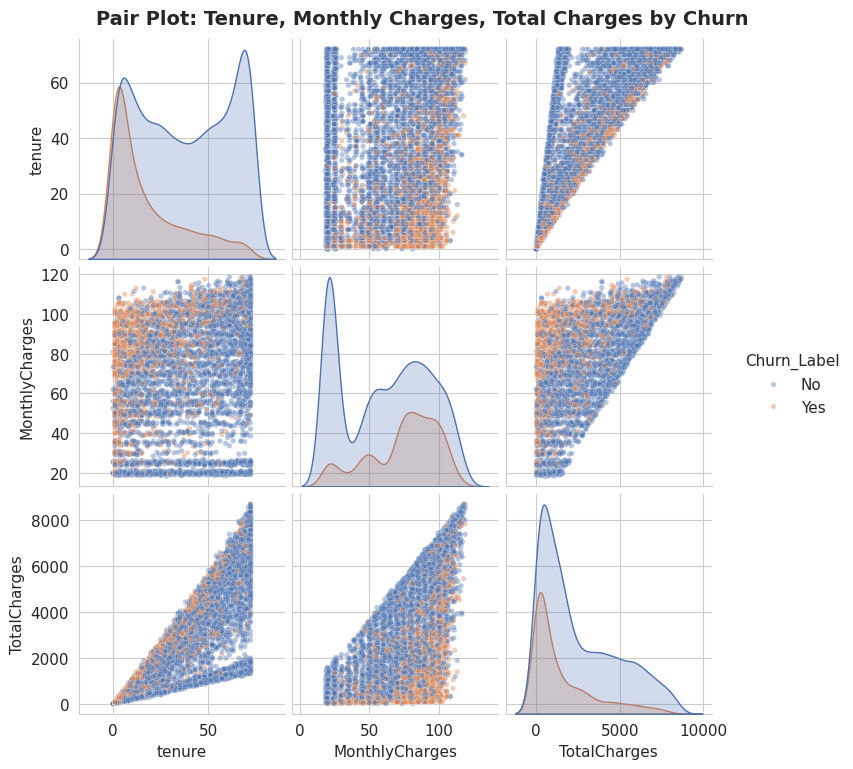

In [8]:
pairplot_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Label']].copy()
g = sns.pairplot(pairplot_df, hue='Churn_Label', palette=['#4C72B0', '#DD8452'],
                  diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
g.figure.suptitle('Pair Plot: Tenure, Monthly Charges, Total Charges by Churn', y=1.02, fontsize=14, fontweight='bold')
g.savefig('charts/06_pairplot_numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** The pair plot shows `tenure` and `TotalCharges` are strongly positively related (expected, since total charges accumulate over time), while `MonthlyCharges` is largely independent of tenure. The clearest separation between churned and retained customers appears in the `tenure` distributions and the `tenure` vs `TotalCharges` scatter, where churned customers cluster tightly in the low-tenure, low-total-charges corner.

## 11. Contract vs Churn

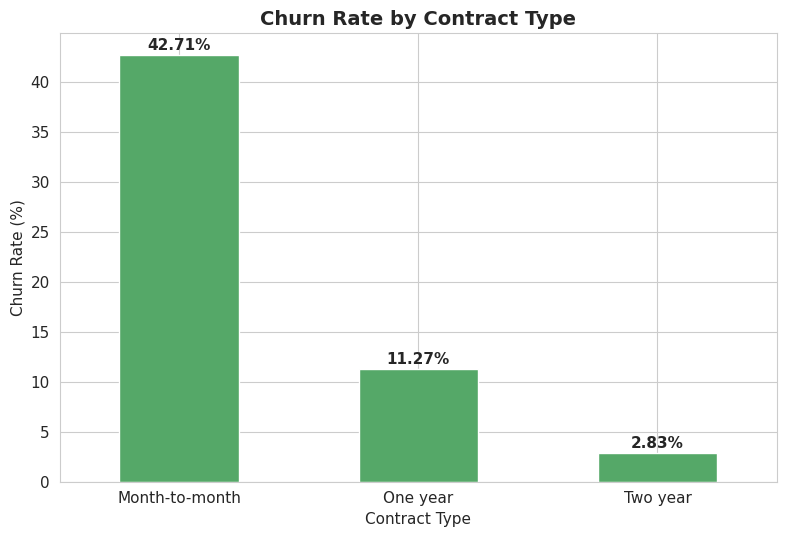

In [9]:
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).round(2).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5.5))
contract_churn.plot(kind='bar', ax=ax, color='#55A868')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Contract Type')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(contract_churn):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/07_contract_vs_churn.png', dpi=150)
plt.show()


**Insight:** Month-to-month churn (42.71%) is roughly 15x the two-year contract churn rate (2.83%) — the single largest categorical churn gap in the dataset.

## 12. Payment Method vs Churn

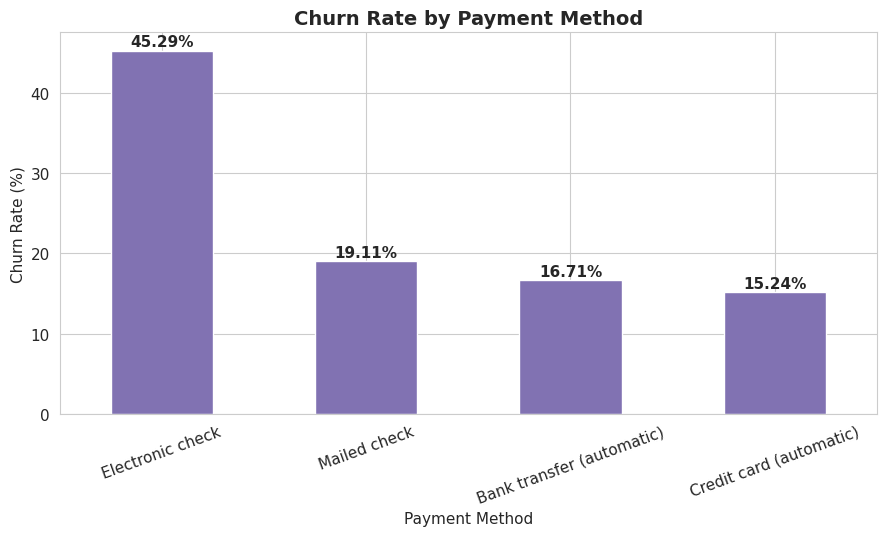

In [10]:
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(2).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5.5))
payment_churn.plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Payment Method')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(payment_churn):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/08_paymentmethod_vs_churn.png', dpi=150)
plt.show()


**Insight:** Electronic check (45.29%) stands out well above the other three payment methods, which cluster between 15–19%.

## 13. Demographic Churn (Senior Citizen & Partner)

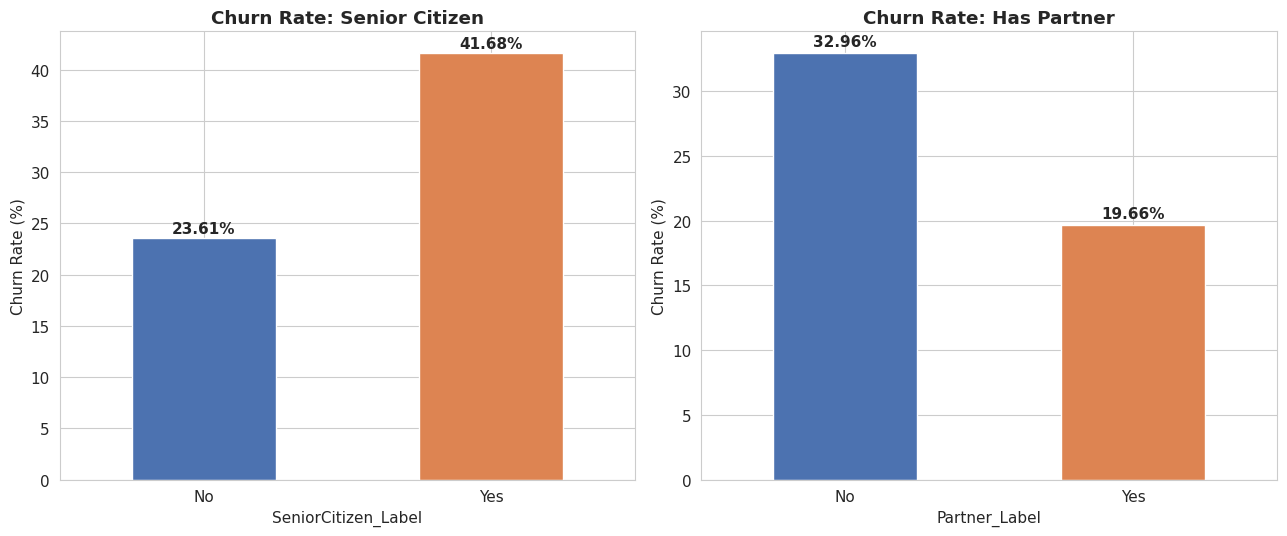

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc = df.assign(SeniorCitizen_Label=df['SeniorCitizen'].map({1:'Yes',0:'No'}))\
       .groupby('SeniorCitizen_Label')['Churn'].mean().mul(100).round(2)
sc.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Churn Rate: Senior Citizen', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(sc):
    axes[0].text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

pt = df.assign(Partner_Label=df['Partner'].map({1:'Yes',0:'No'}))\
       .groupby('Partner_Label')['Churn'].mean().mul(100).round(2)
pt.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Churn Rate: Has Partner', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(pt):
    axes[1].text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/09_demographic_churn.png', dpi=150)
plt.show()


**Insight:** Senior citizens and customers without a partner both churn meaningfully more than their counterparts, matching the Task 2 demographic findings.

## 14. Service-Related Churn (Support Add-Ons)

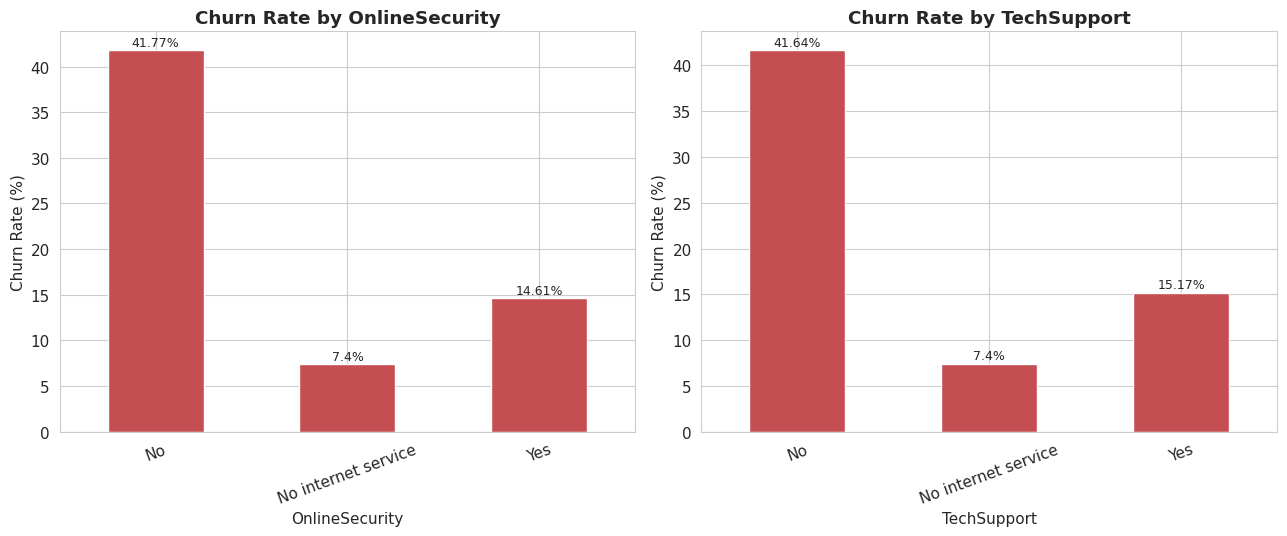

In [12]:
service_cols = ['OnlineSecurity', 'TechSupport']
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, col in zip(axes, service_cols):
    rate = df.groupby(col)['Churn'].mean().mul(100).round(2)
    rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(rate):
        ax.text(i, v + 0.5, f"{v}%", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('charts/10_service_addon_churn.png', dpi=150)
plt.show()


**Insight:** Customers without `TechSupport` or `OnlineSecurity` churn at roughly 2.7x the rate of customers who have these add-ons — one of the largest, most actionable gaps in the dataset (see Task 5 Recommendation 3).

## 15. Segment-Level Churn (Priority Framework)

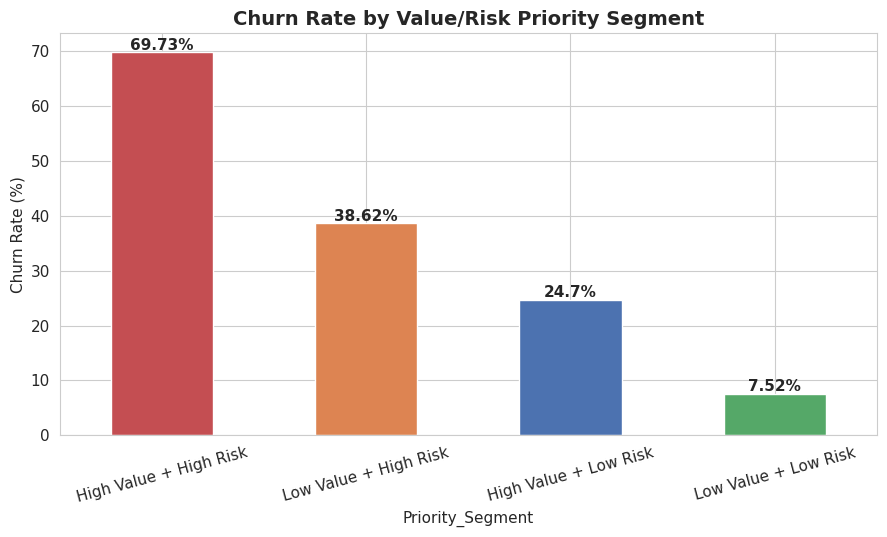

In [13]:
priority_churn = df.groupby('Priority_Segment')['Churn'].mean().mul(100).round(2).sort_values(ascending=False)
colors_map = {'High Value + High Risk': '#C44E52', 'Low Value + High Risk': '#DD8452',
              'High Value + Low Risk': '#4C72B0', 'Low Value + Low Risk': '#55A868'}
bar_colors = [colors_map.get(i, '#888888') for i in priority_churn.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
priority_churn.plot(kind='bar', ax=ax, color=bar_colors)
ax.set_title('Churn Rate by Value/Risk Priority Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(priority_churn):
    ax.text(i, v + 0.5, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/11_segment_priority_churn.png', dpi=150)
plt.show()


**Insight:** The High Value + High Risk segment churns at 69.73%, nearly triple the overall 26.54% baseline, visually confirming this as the top retention-priority group identified in Tasks 3 and 5.

## 16. Model Insight — Feature Importance (from Task 4)

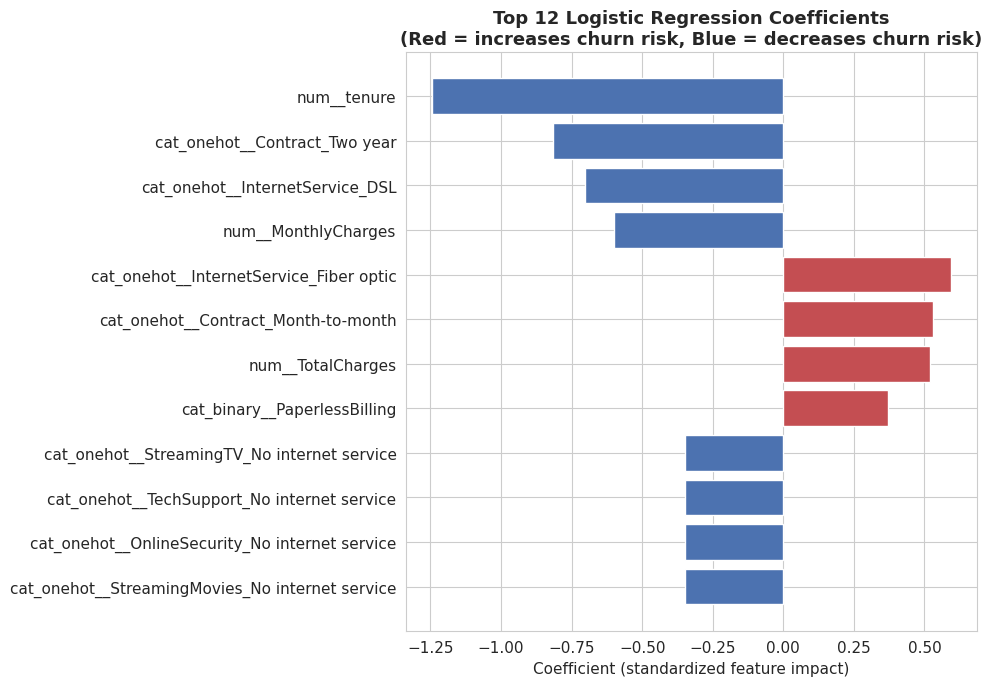

In [14]:
import joblib

pipe = joblib.load('../Task_4_Churn_Prediction_Model/model/churn_logistic_regression_pipeline.joblib')
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C44E52' if c > 0 else '#4C72B0' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.set_title('Top 12 Logistic Regression Coefficients\n(Red = increases churn risk, Blue = decreases churn risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (standardized feature impact)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/12_model_feature_importance.png', dpi=150)
plt.show()


**Insight:** Loaded directly from the Task 4 trained model, this confirms tenure, contract type, and internet service type as the dominant churn-risk drivers the model actually learned, matching the independent EDA and segmentation findings.

## 17. Visualization Summary

| # | Chart | Type | File |
|---|---|---|---|
| 1 | Overall churn distribution | Pie | `01_churn_distribution.png` |
| 2 | Tenure distribution | Histogram | `02_tenure_distribution.png` |
| 3 | Monthly charges by churn | **Box plot** | `03_boxplot_monthlycharges_churn.png` |
| 4 | Tenure by churn | **Violin plot** | `04_violinplot_tenure_churn.png` |
| 5 | Total charges by contract, split by churn | **Violin plot** | `05_violinplot_totalcharges_contract.png` |
| 6 | Tenure / Monthly / Total charges relationships | **Pair plot** | `06_pairplot_numeric_features.png` |
| 7 | Contract type vs churn | Bar | `07_contract_vs_churn.png` |
| 8 | Payment method vs churn | Bar | `08_paymentmethod_vs_churn.png` |
| 9 | Demographic churn (senior citizen, partner) | Bar | `09_demographic_churn.png` |
| 10 | Service add-on churn | Bar | `10_service_addon_churn.png` |
| 11 | Segment-level priority churn | Bar | `11_segment_priority_churn.png` |
| 12 | Model feature importance | Horizontal bar | `12_model_feature_importance.png` |

## 18. Task 6 Conclusion
This notebook consolidates the project's visual evidence, including the box plot, violin plot, and
pair plot required by the brief, into one place with each chart saved as a standalone PNG in
`charts/`. Every visualization here reproduces or extends a finding already established
quantitatively in Tasks 2–4, giving the project a consistent story from raw numbers through to
visual communication.